# 🧬 Demonstração — Otimização de Diagnóstico via Algoritmo Genético + LLM

**Tech Challenge Fase 2 — FIAP Postech IA para Devs**

Este notebook demonstra, ponta a ponta:
1. Otimização de hiperparâmetros do modelo de diagnóstico via **Algoritmo Genético**;
2. Comparação **original (Fase 1) vs otimizado**;
3. Interpretação clínica do diagnóstico via **LLM local** (com fallback);
4. Avaliação objetiva da **qualidade** da interpretação.

## 0. Setup

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')  # torna o pacote diag_opt importável

import matplotlib.pyplot as plt
from diag_opt.data import load_dataset, class_distribution

## 1. Dataset (mesmo da Fase 1)

In [2]:
ds = load_dataset()
print('Amostras:', ds.X.shape[0], '| Features:', ds.X.shape[1])
print('Distribuição:', class_distribution(ds.y))
print('Treino:', ds.X_train.shape[0], '| Teste:', ds.X_test.shape[0])

Amostras: 569 | Features: 30
Distribuição: {'maligno': 212, 'benigno': 357}
Treino: 455 | Teste: 114


## 2. Otimização via Algoritmo Genético (SVM)

Rodamos o GA para otimizar `C`, `gamma` e `kernel` do SVM. A fitness usa
validação cruzada 5-fold ponderando **recall(maligno)**, F1 e AUC.

In [3]:
from diag_opt.ga.fitness import FitnessEvaluator
from diag_opt.ga.engine import GeneticOptimizer, GAConfig

evaluator = FitnessEvaluator('SVM', ds.X, ds.y)
config = GAConfig(population_size=20, generations=15, seed=42)
history = []
opt = GeneticOptimizer('SVM', evaluator, config, on_generation=history.append)
result = opt.run()

print('Melhores hiperparâmetros:', result.best_chromosome)
print(f'Fitness (CV): {result.best_fitness:.4f}')
print(f'Avaliações: {result.n_evaluations} | Tempo: {result.elapsed_seconds:.1f}s')

Melhores hiperparâmetros: {'C': 2.606835083153345, 'gamma': 0.03363383896644277, 'kernel': 'rbf'}
Fitness (CV): 0.9726
Avaliações: 99 | Tempo: 9.9s


### Curva de convergência

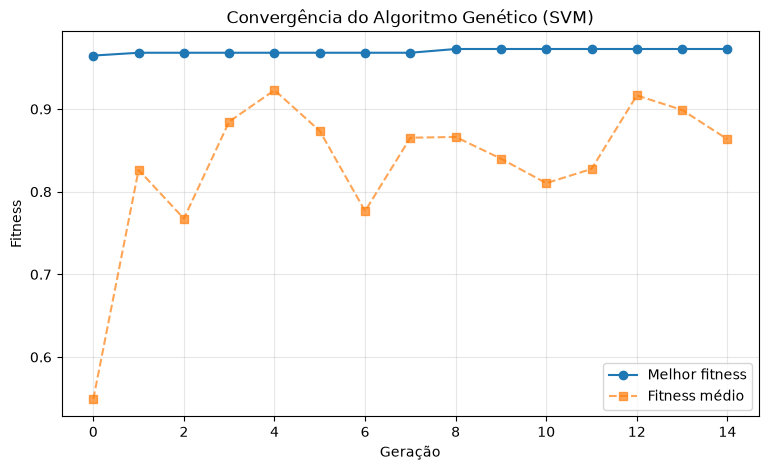

In [4]:
gens = [h.generation for h in history]
best = [h.best_fitness for h in history]
mean = [h.mean_fitness for h in history]

plt.figure(figsize=(9,5))
plt.plot(gens, best, 'o-', label='Melhor fitness')
plt.plot(gens, mean, 's--', label='Fitness médio', alpha=0.7)
plt.xlabel('Geração'); plt.ylabel('Fitness')
plt.title('Convergência do Algoritmo Genético (SVM)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 3. Comparação: original (Fase 1) vs otimizado

In [5]:
from diag_opt.evaluation import compare_baseline_vs_optimized

comp = compare_baseline_vs_optimized('SVM', result.best_chromosome, ds)
for nome, ev in comp.items():
    m = ev.metrics
    print(f"{nome:>10} | acc={m['accuracy']:.4f} recall={m['recall_maligno']:.4f} "
          f"f1={m['f1_maligno']:.4f} | FN={ev.false_negatives} FP={ev.false_positives}")

  baseline | acc=0.9825 recall=0.9762 f1=0.9762 | FN=1 FP=1
 optimized | acc=0.9737 recall=0.9762 f1=0.9647 | FN=1 FP=2


### Gradient Boosting — onde o GA mais agrega

O SVM da Fase 1 já era quase ótimo. Para evidenciar o ganho do GA, aplicamos
a um modelo com baseline mais fraco. **Atenção: esta célula é mais lenta.**

In [6]:
ev_gb = FitnessEvaluator('GradientBoosting', ds.X, ds.y)
res_gb = GeneticOptimizer('GradientBoosting', ev_gb, GAConfig(population_size=20, generations=15, seed=42)).run()
comp_gb = compare_baseline_vs_optimized('GradientBoosting', res_gb.best_chromosome, ds)
for nome, e in comp_gb.items():
    print(f"{nome:>10} | recall={e.metrics['recall_maligno']:.4f} | FN={e.false_negatives}")

  baseline | recall=0.9048 | FN=4
 optimized | recall=0.9286 | FN=3


## 4. Interpretação clínica via LLM local

Treinamos o modelo de serviço (com probabilidades calibradas) e pedimos ao
LLM uma interpretação para um caso **maligno** do conjunto de teste.
Se o LLM não estiver no ar, o sistema usa um **fallback determinístico**.

In [7]:
import numpy as np
from diag_opt.evaluation import fit_serving_model
from diag_opt.llm.client import LLMClient
from diag_opt.llm.interpreter import interpret_patient

pipe = fit_serving_model('SVM', result.best_chromosome, ds)
client = LLMClient()
print('LLM disponível:', client.is_available())

idx = int(np.where(ds.y_test.values == 0)[0][0])  # primeiro caso maligno
interp = interpret_patient(pipe, ds, idx, client=client)
print('Fonte:', interp.source, '| p(maligno) = %.3f' % interp.context['probability_malignant'])
print()
print(interp.text)

LLM disponível: True


Fonte: llm | p(maligno) = 0.993

## Resumo  
O modelo prediz com alta confiança (99.3%) que o lesão apresenta características compatíveis com um carcinoma maligno. A predição é baseada em desvios significativos em parâmetros de forma e textura celular.

## Fatores que mais influenciaram  
- **Perimeter error (7.16)**: valor 2,2 desvios-padrão acima da média, indicando irregularidade na forma perimetral das células, típica de tumores malignos.  
- **Worst perimeter (178.60)**: valor 2,2 desvios-padrão acima da média, reflete uma grande variabilidade na perimetral das células mais desfavoráveis, associada a crescimento anormal e invasivo.  
- **Mean texture (28.77)**: valor 2,2 desvios-padrão acima da média, sugere heterogeneidade na superfície celular, comum em carcinomas malignos.  
- **Mean compactness (0.21)**: valor 1,9 desvios-padrão acima da média, indica menor densidade celular e maior dispersão, características frequentes em tumores invasivos.

## Recomendação de conduta  
O pac

## 5. Avaliação objetiva da qualidade da interpretação

In [8]:
from diag_opt.llm.quality import evaluate_interpretation

report = evaluate_interpretation(interp.text, interp.context)
print(f'Score de qualidade: {report.score:.2f}')
for criterio, ok in report.checks.items():
    print(f'  {"✅" if ok else "❌"} {criterio}')

Score de qualidade: 0.86
  ✅ estrutura
  ✅ seguranca_clinica
  ✅ prudencia
  ❌ sem_afirmacao_categorica
  ✅ grounding_nos_dados
  ✅ idioma_ptbr
  ✅ tamanho_adequado


---

**Conclusão:** o Algoritmo Genético confirma a excelência do SVM da Fase 1 e
reduz um falso negativo no Gradient Boosting; o LLM local traduz o diagnóstico
em linguagem clínica acionável, com privacidade (dados não saem da rede) e
avaliação objetiva de qualidade.